# 单词的向量表示以及距离计算

In [1]:
%pip install gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
    --------------------------------------- 0.5/24.4 MB 8.5 MB/s eta 0:00:03
   --- ------------------------------------ 2.4/24.4 MB 8.4 MB/s eta 0:00:03
   -------- ------------------------------- 5.2/24.4 MB 11.0 MB/s eta 0:00:02
   --------- ------------------------------ 5.5/24.4 MB 9.1 MB/s eta 0:00:03
   --------------- ------------------------ 9.2/24.4 MB 10.6 MB/s eta 0:00:02
   ------------------ --------------------- 11.5/24.4 MB 10.6 MB/s eta 0:00:02
   ----------------------- ---------------- 14.2/24.4 MB 11.7 MB/s eta 0:00:01
   --------------------------- ------------ 16.8/24.4 MB 11.2 MB/s eta 0:00:01
   ---------------------------- ----------- 17.3/24.4 MB 11.1 MB/s eta 0:00:01
   ----------------------------------- ---- 21.8/24.4 MB 11.4 MB/s eta 0:00:01
   ---------------------------------------  24.1/24.4 MB 11.4 MB/s eta 0:00:01
   ---------------------------------------- 24.4/24.4 MB 11.2 MB/s et


[notice] A new release of pip is available: 25.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import gensim.downloader
model = gensim.downloader.load('glove-wiki-gigaword-100')
model["cat"] #查看'cat'单词的向量表示   

array([ 0.23088  ,  0.28283  ,  0.6318   , -0.59411  , -0.58599  ,
        0.63255  ,  0.24402  , -0.14108  ,  0.060815 , -0.7898   ,
       -0.29102  ,  0.14287  ,  0.72274  ,  0.20428  ,  0.1407   ,
        0.98757  ,  0.52533  ,  0.097456 ,  0.8822   ,  0.51221  ,
        0.40204  ,  0.21169  , -0.013109 , -0.71616  ,  0.55387  ,
        1.1452   , -0.88044  , -0.50216  , -0.22814  ,  0.023885 ,
        0.1072   ,  0.083739 ,  0.55015  ,  0.58479  ,  0.75816  ,
        0.45706  , -0.28001  ,  0.25225  ,  0.68965  , -0.60972  ,
        0.19578  ,  0.044209 , -0.31136  , -0.68826  , -0.22721  ,
        0.46185  , -0.77162  ,  0.10208  ,  0.55636  ,  0.067417 ,
       -0.57207  ,  0.23735  ,  0.4717   ,  0.82765  , -0.29263  ,
       -1.3422   , -0.099277 ,  0.28139  ,  0.41604  ,  0.10583  ,
        0.62203  ,  0.89496  , -0.23446  ,  0.51349  ,  0.99379  ,
        1.1846   , -0.16364  ,  0.20653  ,  0.73854  ,  0.24059  ,
       -0.96473  ,  0.13481  , -0.0072484,  0.33016  , -0.1236

In [3]:
model["cat"].shape

(100,)

In [4]:
model.most_similar("man")

[('woman', 0.8323495388031006),
 ('boy', 0.7914870977401733),
 ('one', 0.7788748741149902),
 ('person', 0.7526816725730896),
 ('another', 0.7522234916687012),
 ('old', 0.7409117221832275),
 ('life', 0.7371697425842285),
 ('father', 0.7370322346687317),
 ('turned', 0.7347694635391235),
 ('who', 0.7345511317253113)]

In [5]:
model.similarity("man", "woman")

np.float32(0.8323495)

In [6]:
model.similarity("king", "queen")

np.float32(0.7507691)

In [7]:
model.most_similar("king")

[('prince', 0.7682328820228577),
 ('queen', 0.7507690787315369),
 ('son', 0.7020888328552246),
 ('brother', 0.6985775232315063),
 ('monarch', 0.6977890729904175),
 ('throne', 0.6919989585876465),
 ('kingdom', 0.6811409592628479),
 ('father', 0.6802029013633728),
 ('emperor', 0.6712858080863953),
 ('ii', 0.6676074266433716)]

In [8]:
m = model["king"] - model["man"] + model["woman"]
model.most_similar(m)

[('king', 0.8551837205886841),
 ('queen', 0.783441424369812),
 ('monarch', 0.6933802366256714),
 ('throne', 0.6833109855651855),
 ('daughter', 0.6809081435203552),
 ('prince', 0.6713141798973083),
 ('princess', 0.664408266544342),
 ('mother', 0.6579325795173645),
 ('elizabeth', 0.6563301086425781),
 ('father', 0.6392418742179871)]

In [9]:
m = model["father"] - model["man"] + model["woman"]
model.most_similar(m)

[('mother', 0.9137228727340698),
 ('daughter', 0.8749410510063171),
 ('father', 0.8659167289733887),
 ('wife', 0.8636062741279602),
 ('husband', 0.8385112881660461),
 ('grandmother', 0.8167358636856079),
 ('sister', 0.7944929003715515),
 ('woman', 0.7886242270469666),
 ('married', 0.7882137298583984),
 ('son', 0.7741045951843262)]

自注意力机制 (Self-Attention): 对每个查询token，计算与所有key的相似度，加权求和value。公式: Attention(Q,K,V) = softmax(QK^T/sqrt(d_k))V

In [10]:
import numpy as np

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / e_x.sum(axis=-1, keepdims=True)

# 定义 Q, K, V 矩阵: 3个token, d_model=4
np.random.seed(0)
Q = np.random.rand(3, 4)
K = np.random.rand(3, 4)
V = np.random.rand(3, 4)

d_k = Q.shape[-1]
scores = Q @ K.T / np.sqrt(d_k)
weights = softmax(scores)
output = weights @ V

print("Scores matrix (Q @ K.T / sqrt(d_k)):\n", scores)
print("\nAttention weights (softmax):\n", weights)
print("\nOutput (weighted sum of V):\n", output)


Scores matrix (Q @ K.T / sqrt(d_k)):
 [[0.53201031 0.77483818 0.90604437]
 [0.47363813 0.83135733 0.91438024]
 [0.50231942 0.70748796 1.01383565]]

Attention weights (softmax):
 [[0.26820899 0.341926   0.38986501]
 [0.25100881 0.35895866 0.39003253]
 [0.25670316 0.31516267 0.42813417]]

Output (weighted sum of V):
 [[0.38799283 0.53502878 0.13623257 0.75889379]
 [0.39492337 0.53118004 0.1382761  0.75593604]
 [0.39012207 0.53832171 0.12822185 0.75093991]]


**可视化：注意力机制三步走**

将 Scores、Attention Weights 和 Output 三个中间结果并排展示，帮助理解自注意力的计算流程。

01 — 注意力机制三联热力图（cell 13）
生成的图是3个并排的热力图，展示自注意力从输入到输出的三步计算：

| 子图 | 含义 | 解读方式 |
| ---- | ---- | ---- |
| 左：Scores | Q @ K^T / √d_k — 原始点积相似度矩阵 | 颜色越亮 = 某个 query token 与某个 key token 的向量越「方向一致」（相似度高）。这是未归一化的原始分数，数值范围不固定 |
| 中：Attention Weights | softmax(Scores) — 归一化后的注意力权重 | 每一行之和 = 1。颜色越亮 = 该 query token 越「关注」对应的 key token。这一步把任意大小的分数变成了概率分布，回答了「token A 应该分配多少注意力给 token B」 |
| 右：Output | Weights @ V — 最终输出 | 每个 query token 对所有 key token 的 value 做加权求和后的结果。这就是注意力机制的产物——每个输出位置融合了所有输入位置的信息，权重由中图决定 |


如何教学解读：学生应该理解注意力机制的本质是「加权混合」——先算相似度（左），再归一化成权重（中），最后用权重混合 value 得到输出（右）。在真正的 Transformer 里，Q/K/V 是通过可学习的线性变换从输入生成的，而不是随机矩阵。

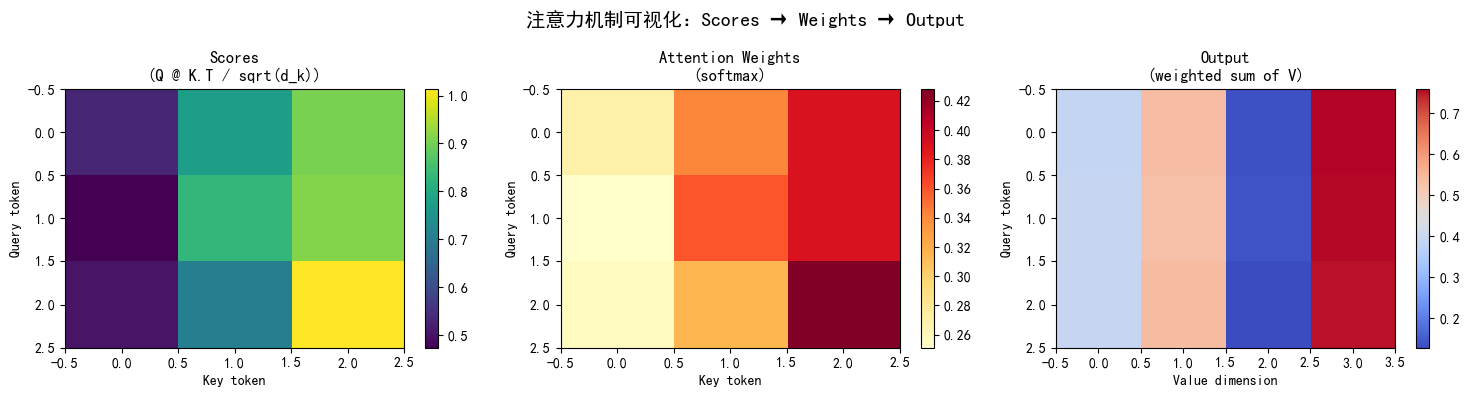

In [11]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im1 = axes[0].imshow(scores, cmap='viridis', aspect='auto')
axes[0].set_title('Scores\n(Q @ K.T / sqrt(d_k))')
axes[0].set_xlabel('Key token')
axes[0].set_ylabel('Query token')
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(weights, cmap='YlOrRd', aspect='auto')
axes[1].set_title('Attention Weights\n(softmax)')
axes[1].set_xlabel('Key token')
axes[1].set_ylabel('Query token')
fig.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(output, cmap='coolwarm', aspect='auto')
axes[2].set_title('Output\n(weighted sum of V)')
axes[2].set_xlabel('Value dimension')
axes[2].set_ylabel('Query token')
fig.colorbar(im3, ax=axes[2])

fig.suptitle('注意力机制可视化：Scores → Weights → Output', fontsize=14)
plt.tight_layout()
plt.show()
